In [40]:
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.integrate
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import numpy as np
from scipy.optimize import least_squares
import pandas as pd

In [41]:
#para
rho_k = 0.002
gamma = 0.70
mu = 8.79/(1000* 52)

In [42]:
df = pd.read_csv("Cases.csv")
weekly_df = df[df["Cumulative"].notna()].copy()

observed_cumulative = weekly_df["Cumulative"].to_numpy() / 1_000_000
t_eval = np.arange(len(observed_cumulative))

In [43]:
#ODE System
def smirk_lambda1(t, y, beta_k, beta_m, phi, lam1, rho_k, gamma, mu):
    Sk, Ik, Rk, Sm, Im, Rm, C = y
    inf_force = beta_k * Ik + beta_m * Im
    mis_pool = Sm + Im + Rm
    mis_force = phi * mis_pool

    dSk = ((-rho_k*Sk) - (Sk * inf_force) - (mis_force * Sk) + (lam1 * Sm) + (mu * (Sk + Ik + Rk)) - mu * Sk)
    dIk = ( (Sk * inf_force) - (gamma * Ik) - (mis_force * Ik) + (lam1 * Im) - (mu * Ik))
    dRk = ((rho_k * Sk) + (gamma * Ik) - (mis_force * Rk) + (lam1 * Rm) - (mu * Rk))
    dSm = (-(Sm * inf_force) + (mis_force * Sk) - (lam1 * Sm) + (mu * (Sm + Im + Rm)) - (mu * Sm))
    dIm = ((Sm * inf_force) - (gamma * Im) + (mis_force * Ik) - (lam1 * Im) - (mu * Im))
    dRm = ((gamma * Im) + (mis_force * Rk) - (lam1 * Rm) - (mu * Rm))

    #Cumulative incidence
    dC = Sk * inf_force + Sm * inf_force

    return [dSk, dIk, dRk, dSm, dIm, dRm, dC]

In [44]:
#Simulate model
def simulate(params, t_eval, y0):
    beta_k, beta_m, phi, lam1 = params

    sol = solve_ivp(smirk_lambda1, t_span = (t_eval[0], t_eval[-1]), y0 = y0, t_eval = t_eval, 
                    args = (beta_k, beta_m, phi, lam1, rho_k, gamma, mu),
                    method = "LSODA")
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y

In [45]:
#residuals for Least-squares 
def residuals(params, t_eval, y0, observed_cumulative):
    states = simulate(params, t_eval, y0)
    C_model = states[6]
    return C_model - observed_cumulative

In [46]:
#One example
t_eval = np.arange(0, len(observed_cumulative), 1)
y0 = [0.60, 0.07, 0.02, 0.30, 0.002, 0.008, observed_cumulative[0]]

#Initial guess for fitted params
x0 = np.array([0.1, 0.3, 0.05, 0.1])
#Bounds
lb = np.array([0, 0, 0, 0.01])
ub = np.array([1.0, 1.5, 0.5, 0.5])

result = least_squares(residuals, x0=x0, bounds=(lb, ub), args = (t_eval, y0, observed_cumulative))

print("Estimated parameters:", result.x)
print("Cost:", result.cost)

Estimated parameters: [0.02301793 0.955725   0.17031857 0.01      ]
Cost: 0.00014269299226204774


In [47]:
beta_k_hat, beta_m_hat, phi_hat, lam1_hat = result.x

In [48]:
#Profile phi

def residuals_profile_phi(params_free, fixed_phi, t_eval, y0, observed_cumulative):
    beta_k, beta_m, lam1 = params_free
    full_params = np.array([beta_k, beta_m, fixed_phi, lam1])
    return residuals(full_params, t_eval, y0, observed_cumulative)


phi_grid = np.linspace(0.001, 0.5, 80)

profile_cost_phi = []
profile_params_phi = []

for fixed_phi in phi_grid:
    x0_free = np.array([result.x[0], result.x[1], result.x[3]])

    lb_free = np.array([0.0, 0.0, 0.01])
    ub_free = np.array([2.0, 2.0, 0.5])

    res_phi = least_squares(
        residuals_profile_phi,
        x0=x0_free,
        bounds=(lb_free, ub_free),
        args=(fixed_phi, t_eval, y0, observed_cumulative)
    )

    profile_cost_phi.append(res_phi.cost)
    profile_params_phi.append(res_phi.x)

profile_cost_phi = np.array(profile_cost_phi)
profile_params_phi = np.array(profile_params_phi)

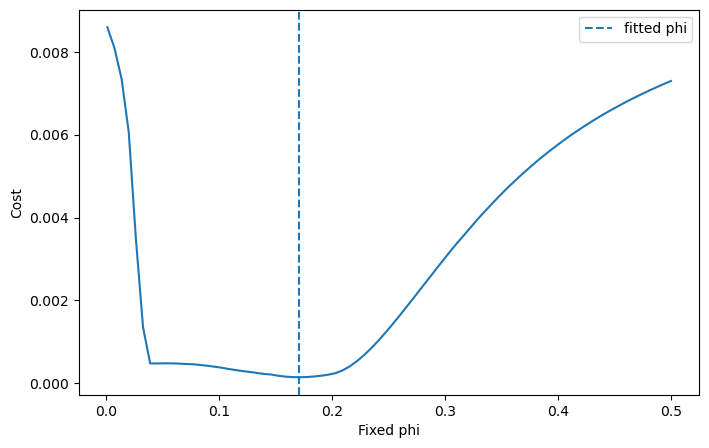

In [49]:
#Plot
plt.figure(figsize=(8, 5))
plt.plot(phi_grid, profile_cost_phi, "-")
plt.axvline(result.x[2], linestyle="--", label="fitted phi")
plt.xlabel("Fixed phi")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.show()

In [50]:
#Profile lambda

def residuals_profile_lambda(params_free, fixed_lam1, t_eval, y0, observed_cumulative):
    beta_k, beta_m, phi = params_free
    full_params = np.array([beta_k, beta_m, phi, fixed_lam1])
    return residuals(full_params, t_eval, y0, observed_cumulative)


lambda_grid = np.linspace(0.01, 0.5, 80)

profile_cost_lambda = []
profile_params_lambda = []

for fixed_lam1 in lambda_grid:
    x0_free = np.array([result.x[0], result.x[1], result.x[2]])

    lb_free = np.array([0.0, 0.0, 0.0])
    ub_free = np.array([2.0, 2.0, 0.5])

    res_lam = least_squares(
        residuals_profile_lambda,
        x0=x0_free,
        bounds=(lb_free, ub_free),
        args=(fixed_lam1, t_eval, y0, observed_cumulative)
    )

    profile_cost_lambda.append(res_lam.cost)
    profile_params_lambda.append(res_lam.x)

profile_cost_lambda = np.array(profile_cost_lambda)
profile_params_lambda = np.array(profile_params_lambda)

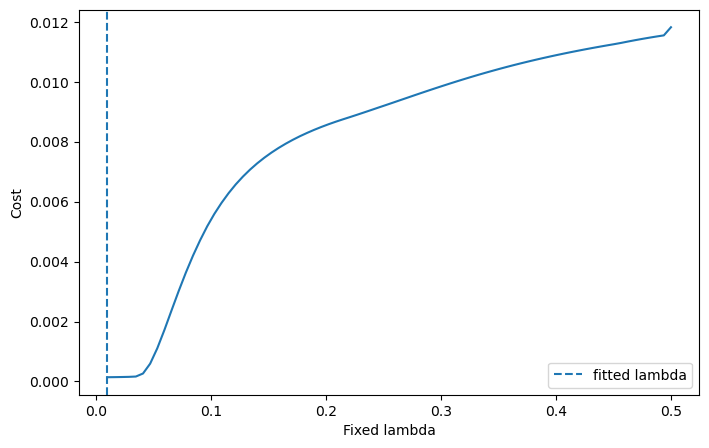

In [51]:
#Plot
plt.figure(figsize=(8, 5))
plt.plot(lambda_grid, profile_cost_lambda, "-")
plt.axvline(result.x[3], linestyle="--", label="fitted lambda")
plt.xlabel("Fixed lambda")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.show()